 # (Single) SAE Feature Analysis
 Feature heatmaps, firing rate histograms, digit distribution analysis,
 and correlation with attention difference (alpha_diff).

In [ ]:
# SETUP

import os
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__file__).parent.parent.parent))

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, ConcatDataset

from src.utils.nb_utils import setup_notebook, load_transformer_model, load_sae
from src.data.datasets import get_dataset
from src.sae.activation_collection import collect_sae_activations, collect_attention_patterns, identify_special_features
from src.sae.metrics import compute_reconstruction_metrics, compute_sae_downstream_metrics
from src.sae.visualization import (
    create_firing_rate_histogram,
    create_feature_heatmaps,
    create_feature_heatmaps_seaborn,
    create_alpha_diff_correlation_plot,
)

DEVICE = setup_notebook(seed=42)

# Create output directory for figures (relative to repo root, not scripts dir)
REPO_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
SAVE_DIR = os.path.join(REPO_ROOT, "results/sae_feat_analysis")
os.makedirs(SAVE_DIR, exist_ok=True)

SAE_NAME   = "sweep_runs_v2/sae_d128_k3_lr0.001_seed1_2layer_100dig_64d.pt" 
# SAE_NAME   = "sweep_k2bsjr0n/btk_sae_d128_k3_lr0.0003_seed3_2layer_100dig_64d.pt"
# ^ better k=3,128 sae! with 2 special feats

# SAE_NAME   = "sweep_xliz4f19/jumprelu_sae_d256_tl05_sp5_lr7e-05_seed1_2layer_100dig_64d.pt"
# SAE_NAME   = "sweep_tbxyl1y7/matryoshka_sae_d128_k3_ng1_lr0.0003_seed12_2layer_100dig_64d.pt"

# TODO - could infer model name from sae config or name
MODEL_NAME = "2layer_100dig_64d"
# MODEL_NAME = "2_layer_sweep/d64_h1_lnF_biasF_wvF_woF_mlpF_s3_acc0.9405"

SPECIAL_THRESH = 0.3 # Threshold for identifying special features

model, model_cfg = load_transformer_model(MODEL_NAME, device=DEVICE)
D_MODEL   = model_cfg["d_model"]
LIST_LEN  = model_cfg["list_len"]
N_DIGITS  = model_cfg["n_digits"]
SEP_IDX   = model_cfg["sep_token_index"]

sae, sae_cfg = load_sae(SAE_NAME, D_MODEL, device=DEVICE)
D_SAE    = sae_cfg["dict_size"]
act_mean = sae_cfg["act_mean"].to(DEVICE)

# Full dataset (train + val) for exhaustive activation collection
train_ds, val_ds = get_dataset(n_digits=N_DIGITS, list_len=LIST_LEN, no_dupes=False, train_dupes_only=False)
all_ds  = ConcatDataset([train_ds, val_ds])
all_dl  = DataLoader(all_ds,  batch_size=256, shuffle=False)

val_dl = DataLoader(val_ds, batch_size=256, shuffle=False)

d1_all, d2_all, sae_acts_all = collect_sae_activations(
    model=model, sae=sae, val_dl=all_dl,
    act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

alpha_d1_all, alpha_d2_all = collect_attention_patterns(
    model=model, val_dl=all_dl,
    layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

/home2/nchw73/Year4/L4_Project/list-comp-priv/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu
Parsed model config (old format): 2 layers, 100 digits, 64 d_model, list_len=2
Loading model from /home2/nchw73/Year4/L4_Project/list-comp-priv/models/2layer_100dig_64d.pt
Moving model to device:  cpu
✓ Loaded model from /home2/nchw73/Year4/L4_Project/list-comp-priv/models/2layer_100dig_64d.pt
✓ Loaded btk SAE from /home2/nchw73/Year4/L4_Project/list-comp-priv/results/sae_models/sweep_runs_v2/sae_d128_k3_lr0.001_seed1_2layer_100dig_64d.pt
  - Dictionary size: 128


 ## Cell 0 — SAE summary metrics

In [ ]:
firing_freq = (sae_acts_all > 0).float().mean(dim=0).numpy()
n_dead      = int((sae_acts_all.sum(dim=0) == 0).sum().item())
l0          = float((sae_acts_all > 0).float().sum(dim=1).mean())

# Explained variance
recon_metrics = compute_reconstruction_metrics(
        model=model, sae=sae, val_dl=all_dl,
        act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
    )

downstream = compute_sae_downstream_metrics(
    model=model, sae=sae, val_dl=all_dl,
    act_mean=act_mean, layer_idx=0, sep_idx=SEP_IDX, device=DEVICE,
)

special_info = identify_special_features(sae_acts_all, alpha_d1_all, alpha_d2_all, threshold=SPECIAL_THRESH)

print(f"SAE: {SAE_NAME}")
print(f"{'─'*60}")
print(f"  d_sae:        {D_SAE}")
print(f"  k:            {sae_cfg.get('k', '?')}")
print(f"  L0:           {l0:.2f}")
print(f"  Dead %:       {100 * n_dead / D_SAE:.1f}%  ({n_dead}/{D_SAE})")
print(f"  Exp Var:      {recon_metrics['explained_variance']:.4f}")
print(f"  Baseline CE:  {downstream['baseline_ce']:.4f}")
print(f"  Patched CE:   {downstream['patched_ce']:.4f}")
print(f"  CE Increase:  {downstream['ce_increase']:.4f}")
print(f"  N Special:    {special_info['n_special_features']}")
print(f"{'─'*60}")

# Sort features by total activation; analyse top-N
total_act    = sae_acts_all.sum(dim=0).numpy()
top_features = np.argsort(total_act)[::-1][:20].tolist()

def compute_feature_digit_stats(feat_idx, d1_all, d2_all, sae_acts_all, n_digits):
    active_mask = sae_acts_all[:, feat_idx] > 0
    n_inputs = active_mask.sum().item()
    if n_inputs == 0:
        zeros = np.zeros(n_digits)
        return {"n_inputs": 0, "all_digit_dist": zeros, "d1_digit_dist": zeros, "d2_digit_dist": zeros}

    d1_active = d1_all[active_mask].numpy()
    d2_active = d2_all[active_mask].numpy()
    d1_counts = np.bincount(d1_active, minlength=n_digits)
    d2_counts = np.bincount(d2_active, minlength=n_digits)
    return {
        "n_inputs": n_inputs,
        "all_digit_dist": 100 * (d1_counts + d2_counts) / (2 * n_inputs),
        "d1_digit_dist":  100 * d1_counts / n_inputs,
        "d2_digit_dist":  100 * d2_counts / n_inputs,
    }

feature_stats = {
    fi: compute_feature_digit_stats(fi, d1_all, d2_all, sae_acts_all, N_DIGITS)
    for fi in tqdm(top_features, desc="Computing digit stats")
}

SAE: sweep_runs_v2/sae_d128_k3_lr0.001_seed1_2layer_100dig_64d.pt
────────────────────────────────────────────────────────────
  d_sae:        128
  k:            3
  L0:           3.02
  Dead %:       3.1%  (4/128)
  Exp Var:      0.9919
  Baseline CE:  0.1115
  Patched CE:   0.1796
  CE Increase:  0.0680
  N Special:    2
────────────────────────────────────────────────────────────


Computing digit stats: 100%|██████████| 20/20 [00:00<00:00, 2457.77it/s]


 ## Cell 1 — Firing rate histogram (seaborn)

Firing Rate Distribution (μ=0.0236, σ=0.0559):
────────────────────────────────────────────────────────────
≥3σ from mean       : 0 features
2-3σ from mean      : 0 features
1-2σ from mean      :   2 features
  1. Feature  11: 0.6400
  2. Feature  56: 0.0991
<1σ from mean       : 126 features (not shown)


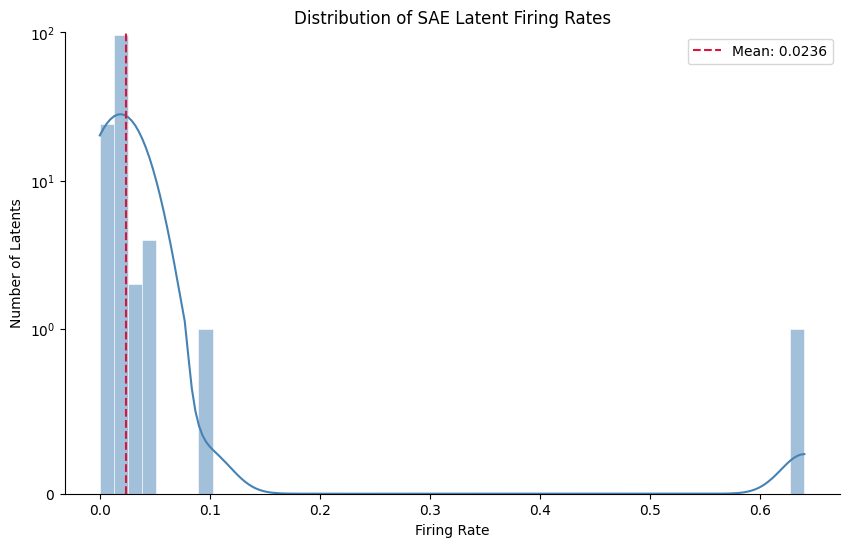


Top 3 latents by firing rate:
Latent     Fire_Rate_%     N_Active  
───────────────────────────────────
11         64.00           6400      
56         9.91            991       
2          4.12            412       


In [ ]:
fig = create_firing_rate_histogram(sae_acts_all, print_top_above_mean=True)
fig.savefig(f"{SAVE_DIR}/01_firing_rate_histogram.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Top 3 latents by firing rate ---
top_3_indices = np.argsort(firing_freq)[-3:][::-1]
print(f"\nTop 3 latents by firing rate:")
print(f"{'Latent':<10} {'Fire_Rate_%':<15} {'N_Active':<10}")
print("─" * 35)
for idx in top_3_indices:
    fire_pct = firing_freq[idx] * 100
    n_active = (sae_acts_all[:, idx] > 0).sum().item()
    print(f"{idx:<10} {fire_pct:<15.2f} {n_active:<10}")

 ## Cell 1b — Latent Type Classification via Greedy Symbol Peeling

In [ ]:
from collections import defaultdict

# ── Hyperparameters ────────────────────────────────────────────────────────
ACTIVATION_THRESHOLD    = 1e-6   # minimum activation to count as "active"
MAGNITUDE_STD_THRESHOLD = 1    # drop activations below (mean - N*std) before peeling
MIN_ACTIVATIONS         = 10     # fewer than this → "near-dead" rather than symbol detector
MIN_CASES_FOR_DETECTION = 10    # (5% of 199) need at least this many activating examples with a symbol to be considered a detector for that symbol. prevents eg. 8-symb detector because it activates on 8 different bigrams but only 1 example per symbol.

# ── Precompute ─────────────────────────────────────────────────────────────
n_inputs_total      = len(sae_acts_all)
special_latent_set  = {f["feature_idx"] for f in special_info["special_features"]}
dead_latent_set     = set(
    int(i) for i in (sae_acts_all.sum(dim=0) == 0)
    .nonzero(as_tuple=False).squeeze(-1).tolist()
)
d1_np, d2_np = d1_all.numpy(), d2_all.numpy()

def peel_symbols(active_mask, act_vals_np, verbose=False):
    """Filter by magnitude then greedily peel symbols. Returns (k, n_filtered, trace)."""
    indices  = np.where(active_mask)[0]
    mags     = act_vals_np[indices]
    keep     = indices[mags >= mags.mean() - MAGNITUDE_STD_THRESHOLD * mags.std()]

    filtered = np.zeros(len(act_vals_np), dtype=bool)
    filtered[keep] = True
    remaining = filtered.copy()

    k, trace = 0, []
    while remaining.any():
        counts  = np.bincount(
            np.concatenate([d1_np[remaining], d2_np[remaining]]),
            minlength=N_DIGITS,
        )
        sym       = int(counts.argmax())
        sym_mask  = (d1_np == sym) | (d2_np == sym)
        n_removed = int(sym_mask[remaining].sum())
        if n_removed < MIN_CASES_FOR_DETECTION:
            break  # stop peeling if no symbol has enough cases left
        if verbose:
            trace.append(f"s{sym}(-{n_removed})")
        remaining &= ~sym_mask
        k += 1
        if k > N_DIGITS:
            break

    return k, int(filtered.sum()), trace

# ── Classify ───────────────────────────────────────────────────────────────
latent_records = []
for latent_idx in tqdm(range(D_SAE), desc="Classifying latents"):
    act_vals    = sae_acts_all[:, latent_idx].numpy()
    active_mask = act_vals > ACTIVATION_THRESHOLD
    n_active    = int(active_mask.sum())
    mean_mag    = float(act_vals[active_mask].mean()) if n_active > 0 else 0.0
    firing_rate = n_active / n_inputs_total

    if latent_idx in dead_latent_set:
        latent_type, k, coverage = "Dead", 0, None
    elif latent_idx in special_latent_set:
        latent_type, k, coverage = "Special", None, None
    elif n_active < MIN_ACTIVATIONS:
        latent_type, k, coverage = "Near-dead", 0, None
    else:
        k, n_filtered, _ = peel_symbols(active_mask, act_vals)
        expected    = k * (2 * N_DIGITS - 1) - k * (k - 1)
        coverage    = n_filtered / expected if expected > 0 else None
        latent_type = f"{k}-symbol"

    latent_records.append({
        "latent_idx": latent_idx, "type": latent_type,
        "n_active": n_active, "firing_rate": firing_rate,
        "mean_mag": mean_mag, "coverage": coverage,
    })

# ── Aggregate and print table ──────────────────────────────────────────────
def _type_sort_key(t):
    if t == "Special":   return -1
    if t == "Near-dead": return 9998
    if t == "Dead":      return 9999
    return int(t.split("-")[0])

def _fmt(vals, scale=1.0, decimals=2, suffix=""):
    if not vals: return "—"
    mu, sd = np.mean(vals) * scale, np.std(vals) * scale
    return f"{mu:.{decimals}f} ± {sd:.{decimals}f}{suffix}"

type_groups = defaultdict(list)
for rec in latent_records:
    type_groups[rec["type"]].append(rec)

table_data = []
for latent_type in sorted(type_groups.keys(), key=_type_sort_key):
    recs = type_groups[latent_type]
    coverages    = [r["coverage"]    for r in recs if r["coverage"] is not None]
    mean_mags    = [r["mean_mag"]    for r in recs]
    firing_rates = [r["firing_rate"] for r in recs]
    table_data.append({
        "Type":            latent_type,
        "Count":           len(recs),
        "% of SAE":        f"{100.0 * len(recs) / D_SAE:.1f}%",
        "Coverage ± std":  _fmt(coverages,    scale=100, decimals=1, suffix="%"),
        "Mean mag ± std":  _fmt(mean_mags,    decimals=3),
        "Fire rate ± std": _fmt(firing_rates, scale=100, decimals=2, suffix="%"),
    })

print("╔══════════════════════════════════════════════════════════════════════════════════════════╗")
print("║                         SAE Latent Type Classification                                  ║")
print("╚══════════════════════════════════════════════════════════════════════════════════════════╝")
print(SAE_NAME)
print(pd.DataFrame(table_data).to_string(index=False))
print(f"\nTotal: {D_SAE}  |  Classified: {sum(len(v) for v in type_groups.values())}")

# ── Up to 3 example latents per type ──────────────────────────────────────
print("\n── Up to 3 example latents per type ─────────────────────────────────────")
for latent_type in sorted(type_groups.keys(), key=_type_sort_key):
    recs     = type_groups[latent_type]
    examples = sorted(recs, key=lambda r: r["coverage"] if r["coverage"] is not None else -1)[:3]
    print(f"\n  [{latent_type}]")
    for r in examples:
        cov_str = f"{r['coverage']*100:.1f}%" if r["coverage"] is not None else "—"
        if r["type"] not in ("Dead", "Near-dead", "Special"):
            act_vals_np = sae_acts_all[:, r["latent_idx"]].numpy()
            active_mask = act_vals_np > ACTIVATION_THRESHOLD
            _, _, trace = peel_symbols(active_mask, act_vals_np, verbose=True)
            sym_str = " → ".join(trace)
        else:
            sym_str = "—"
        print(f"    L{r['latent_idx']:3d} | n_active={r['n_active']:4d} | cov={cov_str:>7} | "
              f"mag={r['mean_mag']:.3f} | fire={r['firing_rate']*100:.2f}% | peel: {sym_str}")

Classifying latents: 100%|██████████| 128/128 [00:00<00:00, 988.14it/s]

╔══════════════════════════════════════════════════════════════════════════════════════════╗
║                         SAE Latent Type Classification                                  ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝
sweep_runs_v2/sae_d128_k3_lr0.001_seed1_2layer_100dig_64d.pt
     Type  Count % of SAE Coverage ± std Mean mag ± std Fire rate ± std
  Special      2     1.6%              —  1.836 ± 0.568  36.95 ± 27.05%
 0-symbol      2     1.6%              —  0.708 ± 0.171    0.11 ± 0.01%
 1-symbol    111    86.7%   82.2 ± 27.0%  2.754 ± 0.781    1.91 ± 0.63%
 2-symbol      4     3.1%    85.9 ± 3.1%  2.517 ± 0.158    4.04 ± 0.05%
Near-dead      5     3.9%              —  0.704 ± 0.325    0.06 ± 0.04%
     Dead      4     3.1%              —  0.000 ± 0.000    0.00 ± 0.00%

Total: 128  |  Classified: 128

── Up to 3 example latents per type ─────────────────────────────────────

  [Special]
    L 11 | n_active=6400 | cov=      

 ## Cell 2 — Digit distribution for top features

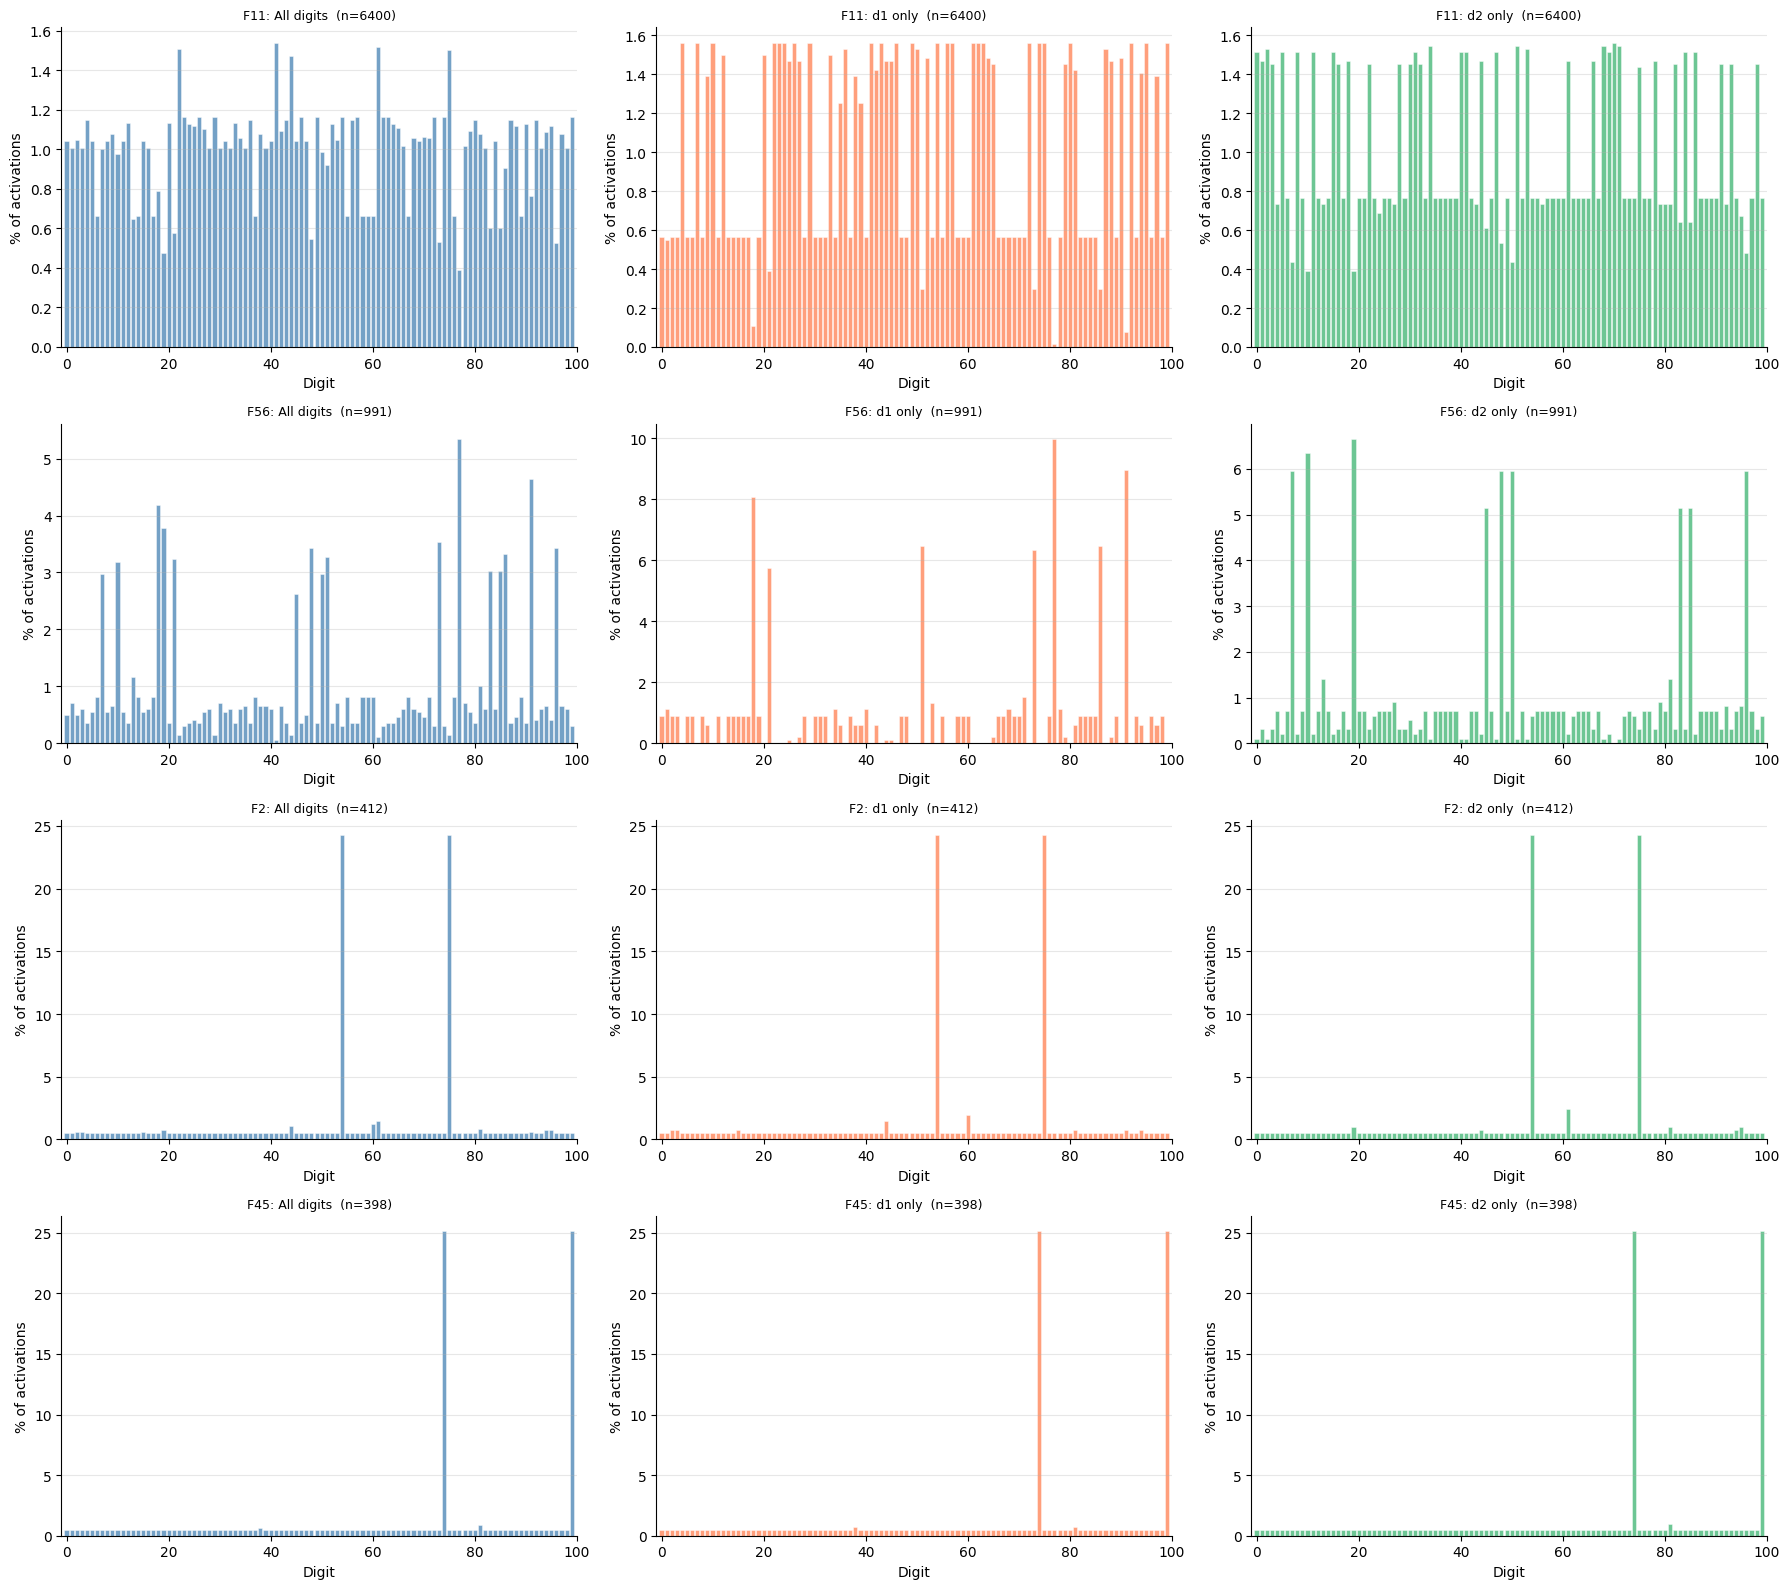

In [ ]:
# --- Visualize: grid of (all | d1 | d2) bar charts for top features ---
n_vis  = min(4, len(top_features))
digits = np.arange(N_DIGITS)

fig, axes = plt.subplots(n_vis, 3, figsize=(18, 4 * n_vis))
if n_vis == 1:
    axes = axes[np.newaxis, :]

col_colours = ["steelblue", "coral", "mediumseagreen"]
col_labels  = ["All digits", "d1 only", "d2 only"]
dist_keys   = ["all_digit_dist", "d1_digit_dist", "d2_digit_dist"]

for idx, fi in enumerate(top_features[:n_vis]):
    stats = feature_stats[fi]
    for c, (key, colour, label) in enumerate(zip(dist_keys, col_colours, col_labels)):
        ax = axes[idx, c]
        dist = stats[key]
        # Only plot non-zero values to avoid spurious bars
        nonzero_mask = dist > 0
        ax.bar(digits[nonzero_mask], dist[nonzero_mask], color=colour, alpha=0.75, edgecolor="white", linewidth=0.4)
        ax.set_xlim(-1, N_DIGITS)
        ax.set_title(f"F{fi}: {label}  (n={stats['n_inputs']})", fontsize=9)
        ax.set_xlabel("Digit")
        ax.set_ylabel("% of activations")
        ax.grid(alpha=0.3, axis="y")
        sns.despine(ax=ax)

plt.tight_layout()
fig.savefig(f"{SAVE_DIR}/02_digit_distribution_top_features.pdf", dpi=150, bbox_inches="tight")
plt.show()

 ## Cell 3 — Full feature heatmap (Plotly interactive)

In [ ]:
fig = create_feature_heatmaps(d1_all, d2_all, sae_acts_all, 
                              n_digits=N_DIGITS, figsize=(25, 25), 
                              shared_scale=False)
fig.write_html(f"{SAVE_DIR}/03_full_feature_heatmap.html")
fig.show()

In [ ]:
# list of top 5 sae features by activation magnitude, along with some max activating examples

 ## Cell 4 — Selected feature heatmaps (seaborn, ~3 types)

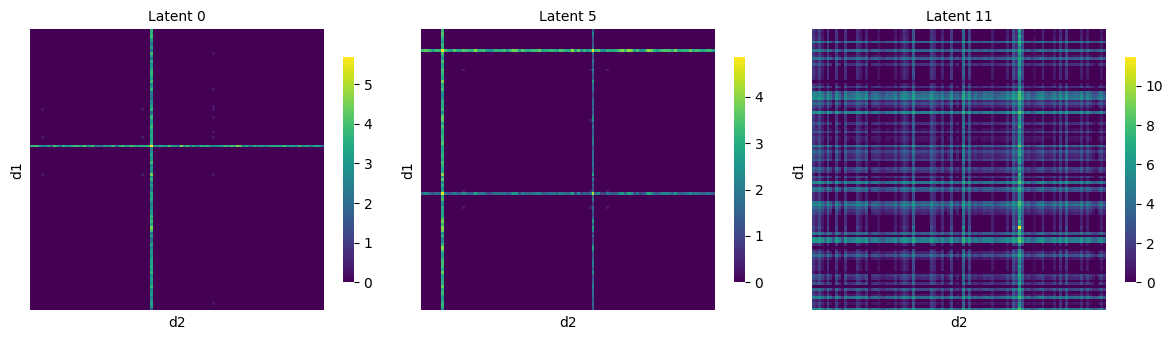

In [ ]:
# Edit this list to compare features of interest
FEATURES_TO_PLOT = [0, 5, 11] # 56
ncols = 3

fig = create_feature_heatmaps_seaborn(
    d1_all, d2_all, sae_acts_all,
    feature_indices=FEATURES_TO_PLOT,
    n_digits=N_DIGITS,
    ncols=ncols,
    shared_scale=False,
)
fig.savefig(f"{SAVE_DIR}/04_selected_features_heatmaps_unscaled.pdf", dpi=150, bbox_inches="tight")
plt.show()

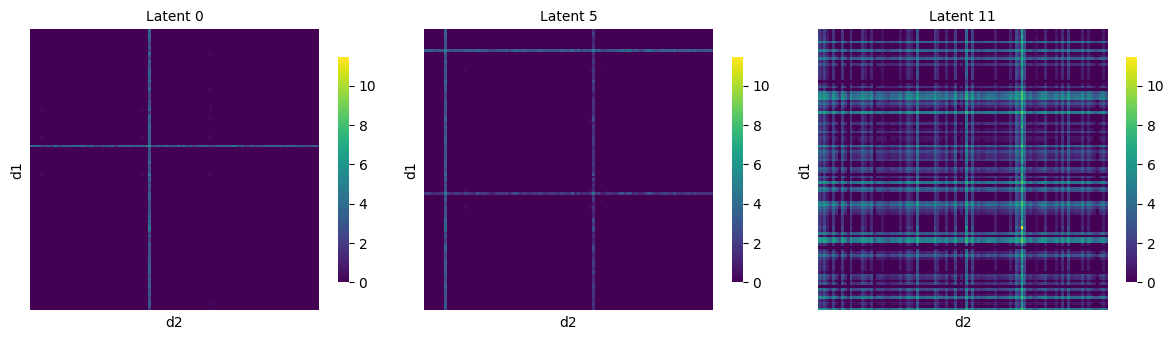

In [ ]:
# w/ shared scale
fig = create_feature_heatmaps_seaborn(
    d1_all, d2_all, sae_acts_all,
    feature_indices=FEATURES_TO_PLOT,
    n_digits=N_DIGITS,
    ncols=ncols,
    shared_scale=True,
)
fig.savefig(f"{SAVE_DIR}/05_selected_features_heatmaps_scaled.pdf", dpi=150, bbox_inches="tight")
plt.show()

 ## Cell 5 — Alpha-diff correlation analysis

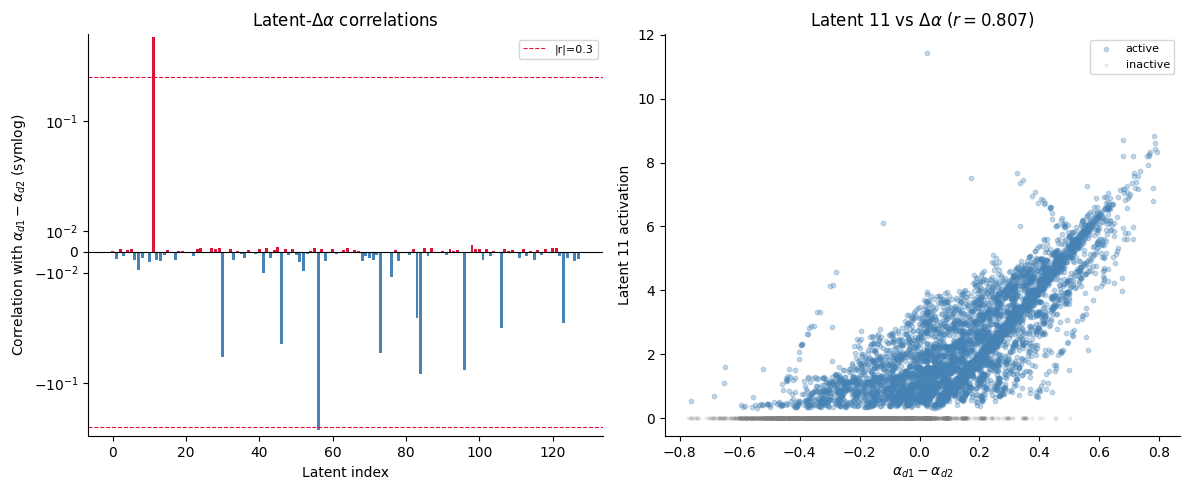


Special features (|r| > 0.3): 2
 Feature  Correlation        Type  Fire_Rate_%  N_Active
      11       0.8073 d1_favoring        64.00      6400
      56      -0.3213 d2_favoring         9.91       991

Top 3 non-special features (|r| ≤ 0.3) by correlation:
 Feature  Correlation        Type  Fire_Rate_% N_Active
      98       0.0036 d1_favoring         2.49        —
      45       0.0023 d1_favoring         3.98      398


In [ ]:
alpha_diff_correlation_plot_idx = 11
fig, correlations = create_alpha_diff_correlation_plot(
    sae_acts_all, alpha_d1_all, alpha_d2_all,
    special_thresh=SPECIAL_THRESH,
    feat_idx=alpha_diff_correlation_plot_idx,
)
fig.savefig(f"{SAVE_DIR}/06_alpha_diff_correlation_plot.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table (reuse special_info from cell 0) ---
info = special_info

rows = []
for feat_info in sorted(info["special_features"], key=lambda x: abs(x["correlation"]), reverse=True):
    fi = feat_info["feature_idx"]
    rows.append({
        "Feature": fi,
        "Correlation": round(feat_info["correlation"], 4),
        "Type": feat_info["type"],
        "Fire_Rate_%": round(float(firing_freq[fi]) * 100, 2),
        "N_Active": feature_stats[fi]["n_inputs"] if fi in feature_stats else "—",
    })

df_special = pd.DataFrame(rows)
print(f"\nSpecial features (|r| > {SPECIAL_THRESH}): {info['n_special_features']}")
print(df_special.to_string(index=False))

# --- Next 3 highest correlating features below threshold ---
print(f"\nTop 3 non-special features (|r| ≤ {SPECIAL_THRESH}) by correlation:")
rows_runner_up = []
for feat_info in info["all_correlations"].argsort()[-3:][::-1]:
    corr = float(info["all_correlations"][feat_info])
    if abs(corr) <= SPECIAL_THRESH:
        rows_runner_up.append({
            "Feature": feat_info,
            "Correlation": round(corr, 4),
            "Type": "d1_favoring" if corr > 0 else "d2_favoring",
            "Fire_Rate_%": round(float(firing_freq[feat_info]) * 100, 2),
            "N_Active": feature_stats[feat_info]["n_inputs"] if feat_info in feature_stats else "—",
        })

if rows_runner_up:
    df_runner_up = pd.DataFrame(rows_runner_up)
    print(df_runner_up.to_string(index=False))
else:
    print("(none found)")

 ## Cell 6 — Bigram-level alignment: special feature vs α_diff

Selected special feature: F11
  Global Pearson r with (α_d1 − α_d2): +0.8073  [d1_favoring]
  Fire rate: 64.0%

  Bigrams with concordant (feature, α_diff) sign: 8070 / 10000
  → 80.7% of all bigrams
  → 86.9% of bigrams with |α_diff| > 0.093 (clear signal)


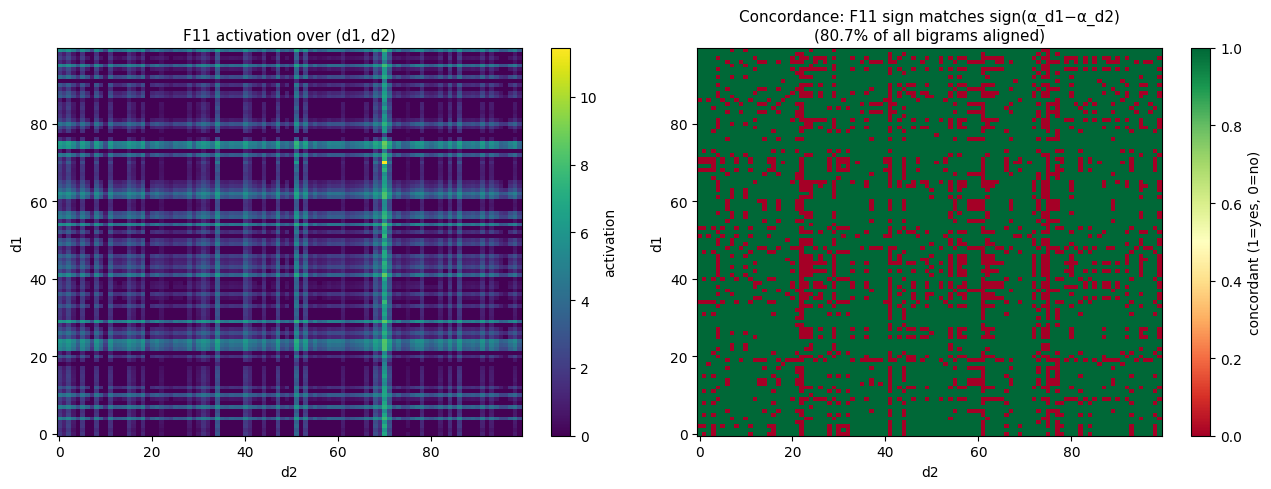

In [ ]:
# Identify the primary special feature and report it
info6 = identify_special_features(sae_acts_all, alpha_d1_all, alpha_d2_all, threshold=SPECIAL_THRESH)

if not info6["special_features"]:
    print(f"No special features found at threshold={SPECIAL_THRESH}")
else:
    primary = info6["special_features"][0] # switch to [0] for strongest corr, or [-1] for most balanced corr
    feat_idx  = primary["feature_idx"]
    feat_corr = primary["correlation"]
    feat_type = primary["type"]

    print(f"Selected special feature: F{feat_idx}")
    print(f"  Global Pearson r with (α_d1 − α_d2): {feat_corr:+.4f}  [{feat_type}]")
    print(f"  Fire rate: {float((sae_acts_all[:, feat_idx] > 0).float().mean()) * 100:.1f}%")

    feat_acts  = sae_acts_all[:, feat_idx].numpy()       # [N]
    alpha_diff = (alpha_d1_all - alpha_d2_all).numpy()   # [N]
    n_total    = len(feat_acts)

    # ── Per-bigram concordance ───────────────────────────────────────────────
    # For a d1-favoring feature (r > 0): expect feat active  when alpha_diff > 0
    #                                          feat inactive  when alpha_diff < 0
    # For a d2-favoring feature (r < 0): reversed.
    feat_active = feat_acts > 0
    alpha_pos   = alpha_diff > 0   # SEP attends more to d1 than d2

    if feat_corr > 0:
        concordant = (feat_active & alpha_pos) | (~feat_active & ~alpha_pos)
    else:
        concordant = (feat_active & ~alpha_pos) | (~feat_active & alpha_pos)

    pct_concordant = 100.0 * concordant.sum() / n_total

    # Only bigrams where the alpha_diff signal is clear (above bottom quartile)
    alpha_abs_thresh = np.percentile(np.abs(alpha_diff), 25)
    clear_mask = np.abs(alpha_diff) > alpha_abs_thresh
    pct_concordant_clear = (
        100.0 * concordant[clear_mask].sum() / clear_mask.sum()
        if clear_mask.any() else float("nan")
    )

    print(f"\n  Bigrams with concordant (feature, α_diff) sign: {concordant.sum()} / {n_total}")
    print(f"  → {pct_concordant:.1f}% of all bigrams")
    print(f"  → {pct_concordant_clear:.1f}% of bigrams with |α_diff| > {alpha_abs_thresh:.3f} (clear signal)")

    # ── Heatmaps ─────────────────────────────────────────────────────────────
    d1_np = d1_all.numpy()
    d2_np = d2_all.numpy()

    act_grid  = np.full((N_DIGITS, N_DIGITS), np.nan)
    conc_grid = np.full((N_DIGITS, N_DIGITS), np.nan)
    for i in range(n_total):
        act_grid [d1_np[i], d2_np[i]] = feat_acts[i]
        conc_grid[d1_np[i], d2_np[i]] = float(concordant[i])

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    im0 = axes[0].imshow(act_grid, origin="lower", aspect="auto", cmap="viridis")
    axes[0].set_title(f"F{feat_idx} activation over (d1, d2)", fontsize=11)
    axes[0].set_xlabel("d2"); axes[0].set_ylabel("d1")
    plt.colorbar(im0, ax=axes[0], label="activation")

    im1 = axes[1].imshow(conc_grid, origin="lower", aspect="auto", cmap="RdYlGn", vmin=0, vmax=1)
    axes[1].set_title(
        f"Concordance: F{feat_idx} sign matches sign(α_d1−α_d2)\n"
        f"({pct_concordant:.1f}% of all bigrams aligned)",
        fontsize=11,
    )
    axes[1].set_xlabel("d2"); axes[1].set_ylabel("d1")
    plt.colorbar(im1, ax=axes[1], label="concordant (1=yes, 0=no)")

    plt.tight_layout()
    fig.savefig(f"{SAVE_DIR}/07_bigram_alignment_heatmaps.pdf", dpi=150, bbox_inches="tight")
    plt.show()

 ## Test feature steering

In [ ]:
from src.sae import *  # Import all SAE analysis utilities

steering_idx = 11  # Use the primary special feature identified above



results = feature_steering_experiment(
    model, sae, act_mean,
    feature_idx=steering_idx,
    d1_all=d1_all, 
    d2_all=d2_all, 
    sae_acts_all=sae_acts_all, 
    dataset=all_ds,
    test_pairs=[(20,49)],
    transpose=True,
    save_dir=SAVE_DIR,
)

crossover_df = analyze_feature_crossovers(
    results=results,
    model=model, sae=sae, act_mean=act_mean,
    feature_idx=steering_idx,
    d1_all=d1_all, d2_all=d2_all, sae_acts_all=sae_acts_all,
    dataset=all_ds,
    layer_idx=0,
    sep_idx=2,
    verbose=True,
)

Using 1 specified input pairs


Test pairs: 100%|██████████| 1/1 [00:02<00:00,  2.86s/it]


Saved plot to /home2/nchw73/Year4/L4_Project/list-comp-priv/results/sae_feat_analysis/feature_11_logit_steering.pdf

CROSSOVER ANALYSIS (exact to 3dp)

Test Case 1: Input (20, 49)
Original feature 11 activation: 1.4032
Original model output: (20, 49)

📍 O1: Found 1 crossover point(s) (linear fit)
   Crossover at scale = 1.5463 (bound=lb)
      → Model output at nearest grid: (49, 20) SWAPPED!

📍 O2: Found 1 crossover point(s)
   Crossover #1 at scale = 1.284 (bound=lb)
      d1 logit = 30.235, d2 logit = 30.518
      → Model output: (20, 49)

--- Swap bounds ---
  Scale range: [1.5500, 2.2000]
  Midpoint: 1.8750,  Width: 0.6500


 ## Co-activation analysis

In [ ]:
# check how many inputs activate latent A, how many activate latent B, and how many are activated by both and by neither (+ any other relvant stats)

# k=5
latentA = 11
latentB = 56

# k=4
# latentA = 11
# latentB = 56

# Extract activations for the two features
acts_A = sae_acts_all[:, latentA] > 0
acts_B = sae_acts_all[:, latentB] > 0

# Count activations
n_total = len(sae_acts_all)
n_A_only = (acts_A & ~acts_B).sum().item()
n_B_only = (~acts_A & acts_B).sum().item()
n_both = (acts_A & acts_B).sum().item()
n_neither = (~acts_A & ~acts_B).sum().item()

n_A = acts_A.sum().item()
n_B = acts_B.sum().item()

# Print statistics
print(f"Feature Co-activation Analysis (Latent {latentA} & {latentB})")
print(f"{'─'*60}")
print(f"  Total inputs:         {n_total}")
print(f"  Activate A only:      {n_A_only:6d}  ({100*n_A_only/n_total:5.1f}%)")
print(f"  Activate B only:      {n_B_only:6d}  ({100*n_B_only/n_total:5.1f}%)")
print(f"  Activate both A & B:  {n_both:6d}  ({100*n_both/n_total:5.1f}%)")
print(f"  Activate neither:     {n_neither:6d}  ({100*n_neither/n_total:5.1f}%)")
print(f"{'─'*60}")
print(f"  Total A activations:  {n_A:6d}  ({100*n_A/n_total:5.1f}%)")
print(f"  Total B activations:  {n_B:6d}  ({100*n_B/n_total:5.1f}%)")

# Mean activation values when active
mean_A_when_active = sae_acts_all[acts_A, latentA].mean().item() if n_A > 0 else 0
mean_B_when_active = sae_acts_all[acts_B, latentB].mean().item() if n_B > 0 else 0
print(f"  Mean A (when active): {mean_A_when_active:7.3f}")
print(f"  Mean B (when active): {mean_B_when_active:7.3f}")

# Create a co-activation contingency table
contingency = np.array([
    [n_neither, n_B_only],
    [n_A_only, n_both]
])
print(f"\nContingency Table:")
print(f"           B inactive  B active")
print(f"A inactive     {n_neither:6d}      {n_B_only:6d}")
print(f"A active       {n_A_only:6d}      {n_both:6d}")

Feature Co-activation Analysis (Latent 11 & 56)
────────────────────────────────────────────────────────────
  Total inputs:         10000
  Activate A only:        6400  ( 64.0%)
  Activate B only:         991  (  9.9%)
  Activate both A & B:       0  (  0.0%)
  Activate neither:       2609  ( 26.1%)
────────────────────────────────────────────────────────────
  Total A activations:    6400  ( 64.0%)
  Total B activations:     991  (  9.9%)
  Mean A (when active):   2.404
  Mean B (when active):   1.268

Contingency Table:
           B inactive  B active
A inactive       2609         991
A active         6400           0


 -------------
 -------------
 -------------
 -------------
 -------------
 -------------